# GraphSAGE Accessibility Modeling
Predict tract-level job accessibility using:
- Census socio-economic variables
- Built environment predictors
- Spatial tract adjacency graph

Target:
- jobs reachable within 30 minutes

In [1]:
# ## Config

# %%
NAME = "Denver"

STATE = "08"

COUNTIES = [
    "031"
]

TARGET_VARIABLE = "jobs_30min"

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

/home/beau/miniconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ## Load Predictor Dataset

# %%
NAME_FILE = NAME.strip().lower().replace(" ", "_")

predictors = pd.read_parquet(
    f"../data/{NAME_FILE}_tract_dataset.parquet"
)

predictors["GEOID"] = (
    predictors["GEOID"]
    .astype(str)
)

print("Predictor shape:", predictors.shape)
print(predictors.head(2))

Predictor shape: (178, 12)
         GEOID  total_population  median_income  population_density  \
0  08031002101              3238       116667.0         2171.817195   
1  08031004404              5961        63966.0         2699.468191   

   pct_under_18  pct_over_65  pct_bachelors_degree  employment_rate  \
0      0.046634     0.059914              0.689031         0.970855   
1      0.207516     0.048482              0.295493         0.877747   

   poverty_rate  road_density  intersection_density  transit_stop_density  
0      0.123224     24.679482             35.548583              5.365824  
1      0.239557     23.916024             39.851233              4.981404  


In [4]:
# ## Load Accessibility Targets

# %%
targets = pd.read_parquet(
    "../data/accessibility/"
    "accessibility_state-CO_counties-031_"
    "year-2023_thresholds-15-30-45-60.parquet"
)

targets["from_id"] = (
    targets["from_id"]
    .astype(str)
)

print("Target shape:", targets.shape)
print(targets.head(2))

Target shape: (178, 5)
       from_id  jobs_15min  jobs_30min  jobs_45min  jobs_60min
0  08031002101     52609.0    277690.0      372564      438107
1  08031004404     11294.0     50630.0      130851      361771


In [5]:
# ## Load Census Tracts

# %%
url = (
    f"https://www2.census.gov/geo/tiger/TIGER2023/"
    f"TRACT/tl_2023_{STATE}_tract.zip"
)

tracts = gpd.read_file(url)

tracts = tracts.to_crs(epsg=4326)

tracts = tracts[
    tracts["COUNTYFP"].isin(COUNTIES)
].copy()

tracts["GEOID"] = (
    tracts["GEOID"]
    .astype(str)
)

print("Tracts:", tracts.shape)

Tracts: (178, 14)


In [6]:
# ## Merge Data

# %%
gdf = tracts.merge(
    predictors,
    on="GEOID",
    how="inner"
)

gdf = gdf.merge(
    targets,
    left_on="GEOID",
    right_on="from_id",
    how="inner"
)

gdf = gpd.GeoDataFrame(
    gdf,
    geometry="geometry"
)

print("Merged shape:", gdf.shape)
print(gdf.head(2))

Merged shape: (178, 30)
  STATEFP COUNTYFP TRACTCE        GEOID               GEOIDFQ   NAME  \
0      08      031  002101  08031002101  1400000US08031002101  21.01   
1      08      031  004404  08031004404  1400000US08031004404  44.04   

             NAMELSAD  MTFCC FUNCSTAT    ALAND  ...  employment_rate  \
0  Census Tract 21.01  G5020        S   880925  ...         0.970855   
1  Census Tract 44.04  G5020        S  1304208  ...         0.877747   

  poverty_rate road_density intersection_density  transit_stop_density  \
0     0.123224    24.679482            35.548583              5.365824   
1     0.239557    23.916024            39.851233              4.981404   

       from_id  jobs_15min  jobs_30min  jobs_45min  jobs_60min  
0  08031002101     52609.0    277690.0      372564      438107  
1  08031004404     11294.0     50630.0      130851      361771  

[2 rows x 30 columns]


In [7]:
# ## Build Spatial Graph

# %%
def build_adjacency_edges(gdf):

    gdf = gdf.copy()

    gdf = gdf[
        gdf.geometry.notnull()
    ]

    gdf = gdf[
        gdf.is_valid
    ]

    sindex = gdf.sindex

    edges = []

    for idx, geom in gdf.geometry.items():

        possible = list(
            sindex.intersection(
                geom.bounds
            )
        )

        candidates = gdf.iloc[possible]

        neighbors = candidates[
            candidates.geometry.intersects(geom)
        ]

        for n_idx in neighbors.index:

            if idx != n_idx:

                edges.append(
                    (idx, n_idx)
                )

    return edges

In [8]:
edges = build_adjacency_edges(gdf)

edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 1016])


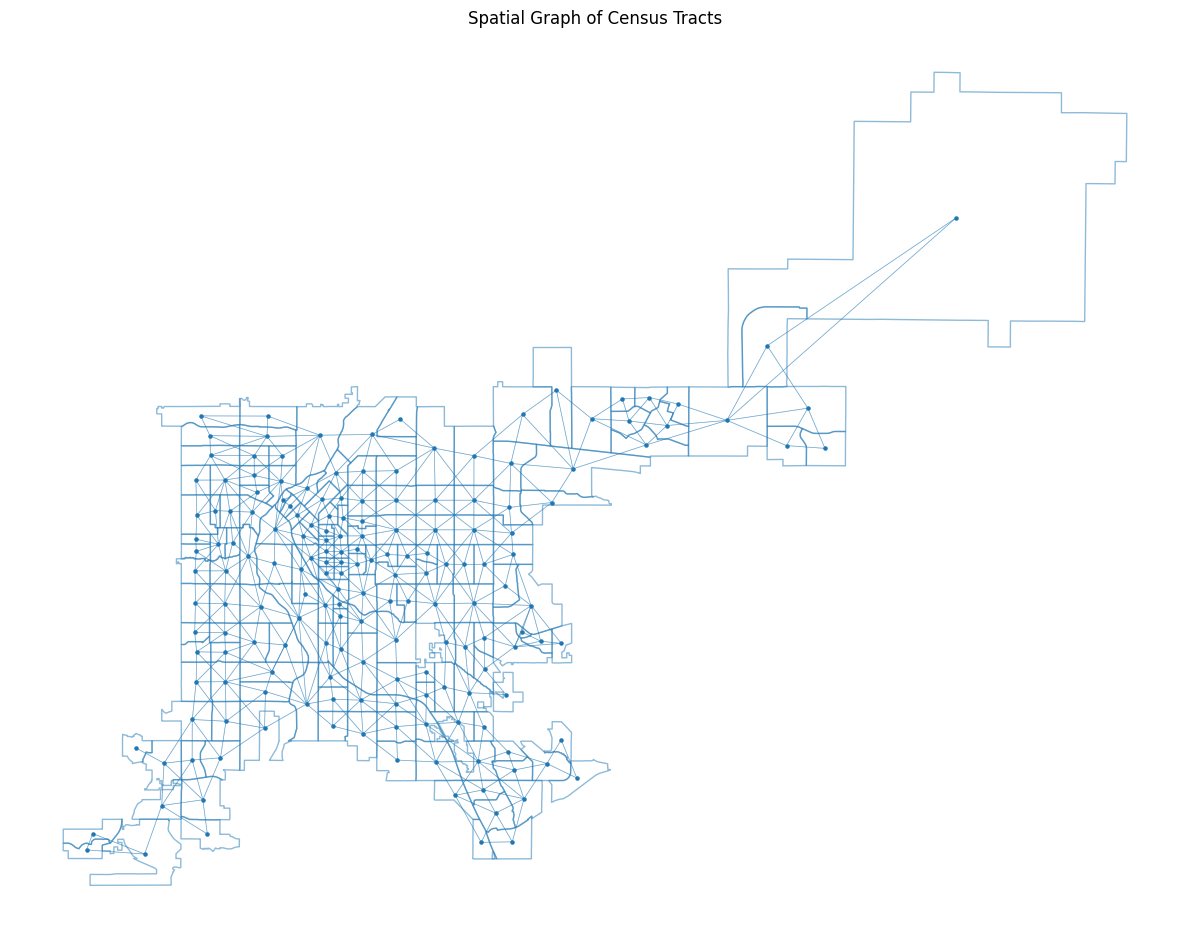

In [9]:
# %%
# ## Plot Spatial Graph

# %%
from shapely.geometry import LineString

# %%
# Compute tract centroids
plot_gdf = gdf.to_crs(epsg=3857).copy()

plot_gdf["centroid"] = (
    plot_gdf.geometry.centroid
)

# %%
# Build edge geometries
edge_lines = []

for source, target in edges:

    source_point = plot_gdf.loc[
        source,
        "centroid"
    ]

    target_point = plot_gdf.loc[
        target,
        "centroid"
    ]

    line = LineString([
        source_point,
        target_point
    ])

    edge_lines.append(line)

# %%
edges_gdf = gpd.GeoDataFrame(
    geometry=edge_lines,
    crs=plot_gdf.crs
)

# %%
# Plot graph
fig, ax = plt.subplots(
    figsize=(12, 12)
)

# tract boundaries
plot_gdf.boundary.plot(
    ax=ax,
    linewidth=1,
    alpha=0.5
)

# graph edges
edges_gdf.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.4
)

# graph nodes
plot_gdf.set_geometry(
    "centroid"
).plot(
    ax=ax,
    markersize=5
)

ax.set_title(
    "Spatial Graph of Census Tracts"
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ## Prepare Node Features

# %%
def prepare_node_features(gdf):

    exclude = [

        "GEOID",
        "from_id",

        "jobs_15min",
        "jobs_30min",
        "jobs_45min",
        "jobs_60min"
    ]

    feature_cols = gdf.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    feature_cols = [
        c for c in feature_cols
        if c not in exclude
    ]

    X = gdf[
        feature_cols
    ].fillna(0).values

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    X = torch.tensor(
        X,
        dtype=torch.float
    )

    return X, feature_cols

In [11]:
X, feature_cols = prepare_node_features(gdf)

print("Feature count:", len(feature_cols))
print(feature_cols)

Feature count: 13
['ALAND', 'AWATER', 'total_population', 'median_income', 'population_density', 'pct_under_18', 'pct_over_65', 'pct_bachelors_degree', 'employment_rate', 'poverty_rate', 'road_density', 'intersection_density', 'transit_stop_density']


In [12]:
# %%
data = Data(
    x=X,
    edge_index=edge_index
)

print(data)

Data(x=[178, 13], edge_index=[2, 1016])


In [13]:
# ## Add Targets

# %%
target_values = np.log1p(
    gdf[TARGET_VARIABLE].values
)

y = torch.tensor(
    target_values,
    dtype=torch.float
)

data.y = y

In [14]:
# ## Train/Test Split

# %%
num_nodes = gdf.shape[0]

idx = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=41
)

train_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    num_nodes,
    dtype=torch.bool
)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask

In [15]:
class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels=64
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.lin = torch.nn.Linear(
            hidden_channels,
            1
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = self.conv2(
            x,
            edge_index
        )

        return self.lin(x).squeeze()

In [16]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = GraphSAGE(
    in_channels=data.x.shape[1]
).to(device)

data = data.to(device)

print(device)

cuda


In [17]:
# ## Training Setup

# %%
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

loss_fn = torch.nn.MSELoss()

In [18]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(
        data.x,
        data.edge_index
    )

    loss = loss_fn(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [19]:
# ## Evaluation Function

# %%
def evaluate():

    model.eval()

    with torch.no_grad():

        out = model(
            data.x,
            data.edge_index
        )

    pred = out[data.test_mask]
    true = data.y[data.test_mask]

    rmse = torch.sqrt(
        loss_fn(pred, true)
    ).item()

    ss_res = (
        (pred - true) ** 2
    ).sum()

    ss_tot = (
        (true - true.mean()) ** 2
    ).sum()

    r2 = (
        1 - ss_res / ss_tot
    ).item()

    return rmse, r2

In [20]:
# ## Train Model

# %%
for epoch in range(1, 1001):

    loss = train()

    if epoch % 20 == 0:

        rmse, r2 = evaluate()

        print(
            f"Epoch {epoch:03d} | "
            f"Loss {loss:.4f} | "
            f"RMSE {rmse:.4f} | "
            f"R2 {r2:.4f}"
        )


Epoch 020 | Loss 4.4815 | RMSE 2.8347 | R2 -5.6374
Epoch 040 | Loss 1.2120 | RMSE 1.1479 | R2 -0.0883
Epoch 060 | Loss 0.7084 | RMSE 1.1106 | R2 -0.0189
Epoch 080 | Loss 0.5266 | RMSE 0.9633 | R2 0.2335
Epoch 100 | Loss 0.4070 | RMSE 0.8690 | R2 0.3762
Epoch 120 | Loss 0.3250 | RMSE 0.8052 | R2 0.4644
Epoch 140 | Loss 0.2604 | RMSE 0.7511 | R2 0.5340
Epoch 160 | Loss 0.2053 | RMSE 0.7176 | R2 0.5746
Epoch 180 | Loss 0.1589 | RMSE 0.6980 | R2 0.5976
Epoch 200 | Loss 0.1193 | RMSE 0.6871 | R2 0.6100
Epoch 220 | Loss 0.0865 | RMSE 0.6845 | R2 0.6130
Epoch 240 | Loss 0.0604 | RMSE 0.6874 | R2 0.6097
Epoch 260 | Loss 0.0414 | RMSE 0.6963 | R2 0.5995
Epoch 280 | Loss 0.0285 | RMSE 0.7063 | R2 0.5879
Epoch 300 | Loss 0.0196 | RMSE 0.7156 | R2 0.5770
Epoch 320 | Loss 0.0139 | RMSE 0.7245 | R2 0.5665
Epoch 340 | Loss 0.0101 | RMSE 0.7279 | R2 0.5623
Epoch 360 | Loss 0.0074 | RMSE 0.7328 | R2 0.5564
Epoch 380 | Loss 0.0054 | RMSE 0.7357 | R2 0.5529
Epoch 400 | Loss 0.0039 | RMSE 0.7380 | R2 0.55

In [21]:
model.eval()

with torch.no_grad():

    pred_log = model(
        data.x,
        data.edge_index
    ).cpu().numpy()

# inverse log transform
pred = np.expm1(pred_log)

gdf["prediction"] = pred

In [22]:
# ## Compute Metrics

# %%
y_true = np.expm1(
    data.y.cpu().numpy()
)

y_test = y_true[
    data.test_mask.cpu()
]

pred_test = pred[
    data.test_mask.cpu()
]

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_test
    )
)

r2 = r2_score(
    y_test,
    pred_test
)

print("\nFinal Metrics")
print("-------------")
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))


Final Metrics
-------------
RMSE: 88968.37
R²: 0.0418


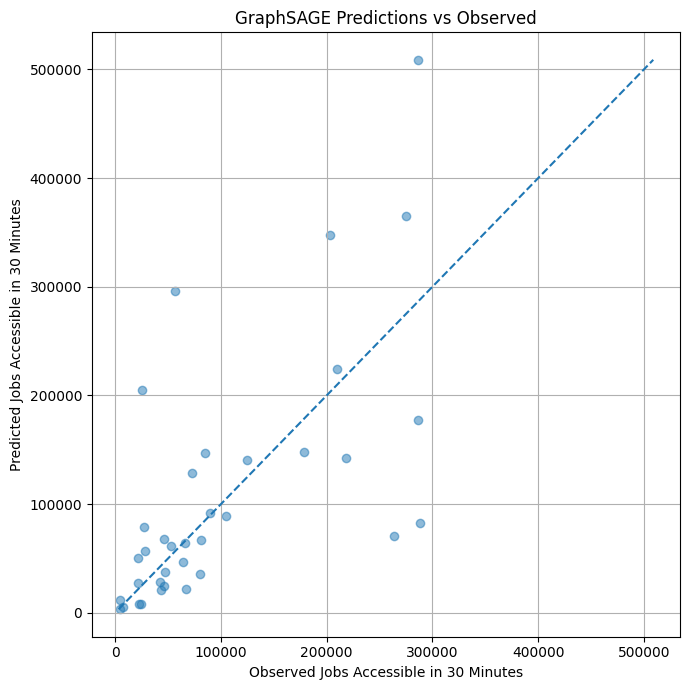

In [23]:
# ## Predicted vs Observed Plot

# %%
fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    y_test,
    pred_test,
    alpha=0.5
)

min_val = min(
    y_test.min(),
    pred_test.min()
)

max_val = max(
    y_test.max(),
    pred_test.max()
)

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

ax.set_xlabel(
    "Observed Jobs Accessible in 30 Minutes"
)

ax.set_ylabel(
    "Predicted Jobs Accessible in 30 Minutes"
)

ax.set_title(
    "GraphSAGE Predictions vs Observed"
)

ax.grid(True)

plt.tight_layout()
plt.show()

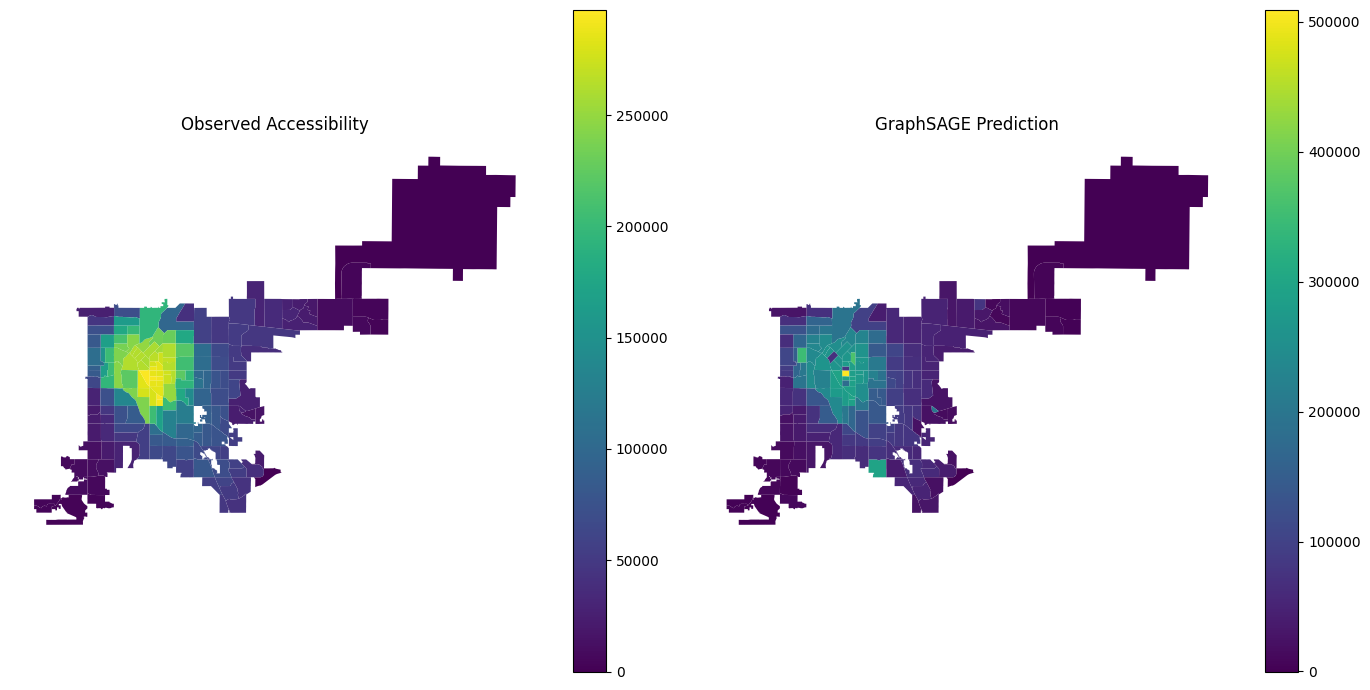

In [24]:
# ## Spatial Visualization

# %%
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7)
)

gdf.plot(
    column=TARGET_VARIABLE,
    cmap="viridis",
    legend=True,
    ax=axes[0]
)

axes[0].set_title(
    "Observed Accessibility"
)

axes[0].axis("off")

gdf.plot(
    column="prediction",
    cmap="viridis",
    legend=True,
    ax=axes[1]
)

axes[1].set_title(
    "GraphSAGE Prediction"
)

axes[1].axis("off")

plt.tight_layout()
plt.show()